# Evaluation with Metrics

Following the FKC paper, we sample 10k samples with 1000 sampling steps.

In [70]:
%reload_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt
import numpy as np
import random, os
from datetime import datetime
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics
from hcg.interpolant import MLPInstFlexible, run_training_v_s
from hcg.sample_data import sample_checkerboard, make_conditions, sample_data_model1, sample_data_model2, sample_data_model3, ground_truth_hcg, plot_diagnostics
from hcg.hcg import simulate_hcg, simulate_hcg_generalized
from hcg.interpolant import Interpolant as Interpolant
from hcg.interpolant import FlowMatcher as FlowMatcher
from hcg.interpolant import plot_path_trajectories as plot_path_trajectories
import json
from IPython.display import clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("device →", device)

top_experiment_id = "#Final_Evaluation_Results#"  # Use a fixed ID for reproducibility
if not os.path.exists(top_experiment_id):
    os.makedirs(top_experiment_id)

model_path = "PretrainedToyModels"

def load_interpolants_from_json(path):
    """Load interpolants.json and return a dict of Interpolant objects."""
    with open(path, "r") as f:
        interpolants_raw = json.load(f)

    interpolants = {}
    for name, funcs in interpolants_raw.items():
        alpha_t = eval(funcs["alpha_t"], {"torch": torch})
        beta_t = eval(funcs["beta_t"], {"torch": torch})
        d_alpha_t = eval(funcs["d_alpha_t"], {"torch": torch})
        d_beta_t = eval(funcs["d_beta_t"], {"torch": torch})
        interpolants[name] = Interpolant(alpha_t, beta_t, d_alpha_t, d_beta_t, name=name)
    return interpolants

interpolant_schedules = load_interpolants_from_json("interpolant_schedules.json")

device → cuda


In [71]:
bs = 10000; n_steps=1000
A, B = 1, 1  # Conditions to use for training
# plot ground truth
# samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).cpu().numpy()
# plot_diagnostics(samples_gt, torch.zeros(bs), [torch.zeros(bs)], save_name=f"{top_experiment_id}/ground_truth")
# clear_output()

# Experiment 1

In [100]:
names = ["default_linear", "custom_poly", "default_linear"]
subexperiment_id = f"{names}"
experiment_id = f"{top_experiment_id}/{subexperiment_id}"
if not os.path.exists(experiment_id):
    os.makedirs(experiment_id)

u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={names[0]}.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={names[0]}.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={names[2]}.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={names[2]}.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={names[1]}.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={names[1]}.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
def sigma_fn(t): return 0.5 * torch.ones_like(t)

v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ]
s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ]
proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ]
emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ]

print("Models loaded.")

Models loaded.


In [102]:
print(u_model1)
print(u_model2)
print(u_model3)

MLPInstFlexible(
  (time_proj): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): SiLU()
  )
  (net): Sequential(
    (0): Linear(in_features=258, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): SiLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): SiLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): SiLU()
    (8): Linear(in_features=256, out_features=1, bias=True)
  )
)
MLPInstFlexible(
  (time_proj): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): SiLU()
  )
  (net): Sequential(
    (0): Linear(in_features=259, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): SiLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): SiLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): SiLU()
    (8): Linear(in_f

In [ ]:
results = []
# seeds=[0,1,2,3,4]
# bs = 5000; n_steps=100
seeds = [0]
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
    print(f"Seed set to {seed}")

    print("Simulating NR")
    gamma_list = [
        lambda t : torch.tensor(1),
        lambda t : torch.tensor(1) * torch.tensor(-1) ,
        lambda t : torch.tensor(1)
    ]
    d_gamma_list = [
        lambda t: torch.zeros_like(t),
        lambda t: torch.zeros_like(t),
        lambda t: torch.zeros_like(t)
    ]
    
    x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
    A, B = 1, 1  # Conditioning values
    samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
        x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
        v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
        t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
        gamma_list=gamma_list,
        d_gamma_list=d_gamma_list,
        resample=False
    )
    samples = samples.cpu().numpy()
    if seed == 0:
        plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_NR")
        plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_NR", deg=-50)
        plt.close(); clear_output()
    
    # print("Evaluating NR")
    # w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
    #     torch.tensor(samples_gt), torch.tensor(samples)
    # )
    # results.append([seed, "NR", w1, w2, mmd_rbf, total_var])

    print("Simulating FKC-H (Constant Gammas)")
    gamma_list = [
        lambda t : torch.tensor(1),
        lambda t : torch.tensor(1) * torch.tensor(-1) ,
        lambda t : torch.tensor(1)
    ]
    d_gamma_list = [
        lambda t: torch.zeros_like(t),
        lambda t: torch.zeros_like(t),
        lambda t: torch.zeros_like(t)
    ]

    x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
    A, B = 1, 1  # Conditioning values
    samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
        x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
        v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
        t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
        gamma_list=gamma_list,
        d_gamma_list=d_gamma_list,
        resample=True
    )
    samples = samples.cpu().numpy()
    if seed == 0:
        plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_FKC-H")
        plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_FKC-H", deg=-50)
        plt.close(); clear_output()

    # print("Evaluating FKC-H")
    # w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
    #     torch.tensor(samples_gt), torch.tensor(samples)
    # )
    # results.append([seed, "FKC-H", w1, w2, mmd_rbf, total_var])

    print("Simulating ACE (Adaptive Gammas)")
    # gamma_list = [
    #     lambda t : torch.tensor(1),
    #     lambda t : torch.tensor(1) * torch.tensor(-1) * torch.tensor((1-2*t)**2),
    #     lambda t : torch.tensor(1)
    # ]
    # d_gamma_list = [
    #     lambda t: torch.zeros_like(t),
    #     lambda t: torch.zeros_like(t) + torch.tensor(-8*t + 4),
    #     lambda t: torch.zeros_like(t)
    # ]
    gamma_list = [
    lambda t : torch.tensor(1) + B * t * (1-t),
    lambda t : torch.tensor(1) * torch.tensor(-1), # * torch.tensor((1-2*t)**2),
    lambda t : torch.tensor(1) + B * t * (1-t)
    ]
    d_gamma_list = [
        lambda t: torch.zeros_like(t) + B * (1-2*t),
        lambda t: torch.zeros_like(t),# + torch.tensor(-8*t + 4),
        lambda t: torch.zeros_like(t) + B * (1-2*t)
    ]

    x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
    A, B = 1, 1  # Conditioning values
    samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
        x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
        v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
        t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
        gamma_list=gamma_list,
        d_gamma_list=d_gamma_list,
        resample=True
    )
    samples = samples.cpu().numpy()
    if seed == 0:
        plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_ACE")
        plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_ACE", deg=-50)
        plt.close(); clear_output()

    # print("Evaluating ACE")
    # w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
    #     torch.tensor(samples_gt), torch.tensor(samples)
    # )
    # results.append([seed, "ACE", w1, w2, mmd_rbf, total_var])

df = pd.DataFrame(results, columns=["seed", "method", "W1", "W2", "MMD_RBF", "Total Var."])
df.to_csv(f"{experiment_id}/experiment_results_numseeds{len(seeds)}_bs{bs}_n_steps{n_steps}.csv", index=False)
print(df)

Empty DataFrame
Columns: [seed, method, W1, W2, MMD_RBF, Total Var.]
Index: []


In [17]:
experiment_id = f"{top_experiment_id}/{subexperiment_id}" + "_t_max=0.85"
if not os.path.exists(experiment_id):
    os.makedirs(experiment_id)
# bs = 5000; n_steps=100
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
print(f"Seed set to {seed}")

# print("Simulating NR")
# gamma_list = [
#     lambda t : torch.tensor(1),
#     lambda t : torch.tensor(1) * torch.tensor(-1) ,
#     lambda t : torch.tensor(1)
# ]
# d_gamma_list = [
#     lambda t: torch.zeros_like(t),
#     lambda t: torch.zeros_like(t),
#     lambda t: torch.zeros_like(t)
# ]

# x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
# A, B = 1, 1  # Conditioning values
# samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
#     x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
#     v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
#     t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
#     gamma_list=gamma_list,
#     d_gamma_list=d_gamma_list,
#     resample=False, t_max = t_max
# )
# samples = samples.cpu().numpy()
# plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_NR")
# # plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_NR", deg=-50)

# print("Evaluating NR")
# w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
#     torch.tensor(samples_gt), torch.tensor(samples)
# )
# print(w1, w2, mmd_rbf, total_var)

Seed set to 0


In [25]:
print("Simulating FKC-H (Constant Gammas)")
gamma_list = [
    lambda t : torch.tensor(1),
    lambda t : torch.tensor(1) * torch.tensor(-1) ,
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t)
]

x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values
samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
    gamma_list=gamma_list,
    d_gamma_list=d_gamma_list,
    resample=True
)
samples = samples.cpu().numpy()
# plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_FKC-H")
# plot_path_trajectories(sample_history, n_frame=4, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_FKC-H", deg=-50)

# print("Evaluating FKC-H")
# samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
# w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
#     torch.tensor(samples_gt), torch.tensor(samples)
# )
# print(w1, w2, mmd_rbf, total_var)

Simulating FKC-H (Constant Gammas)


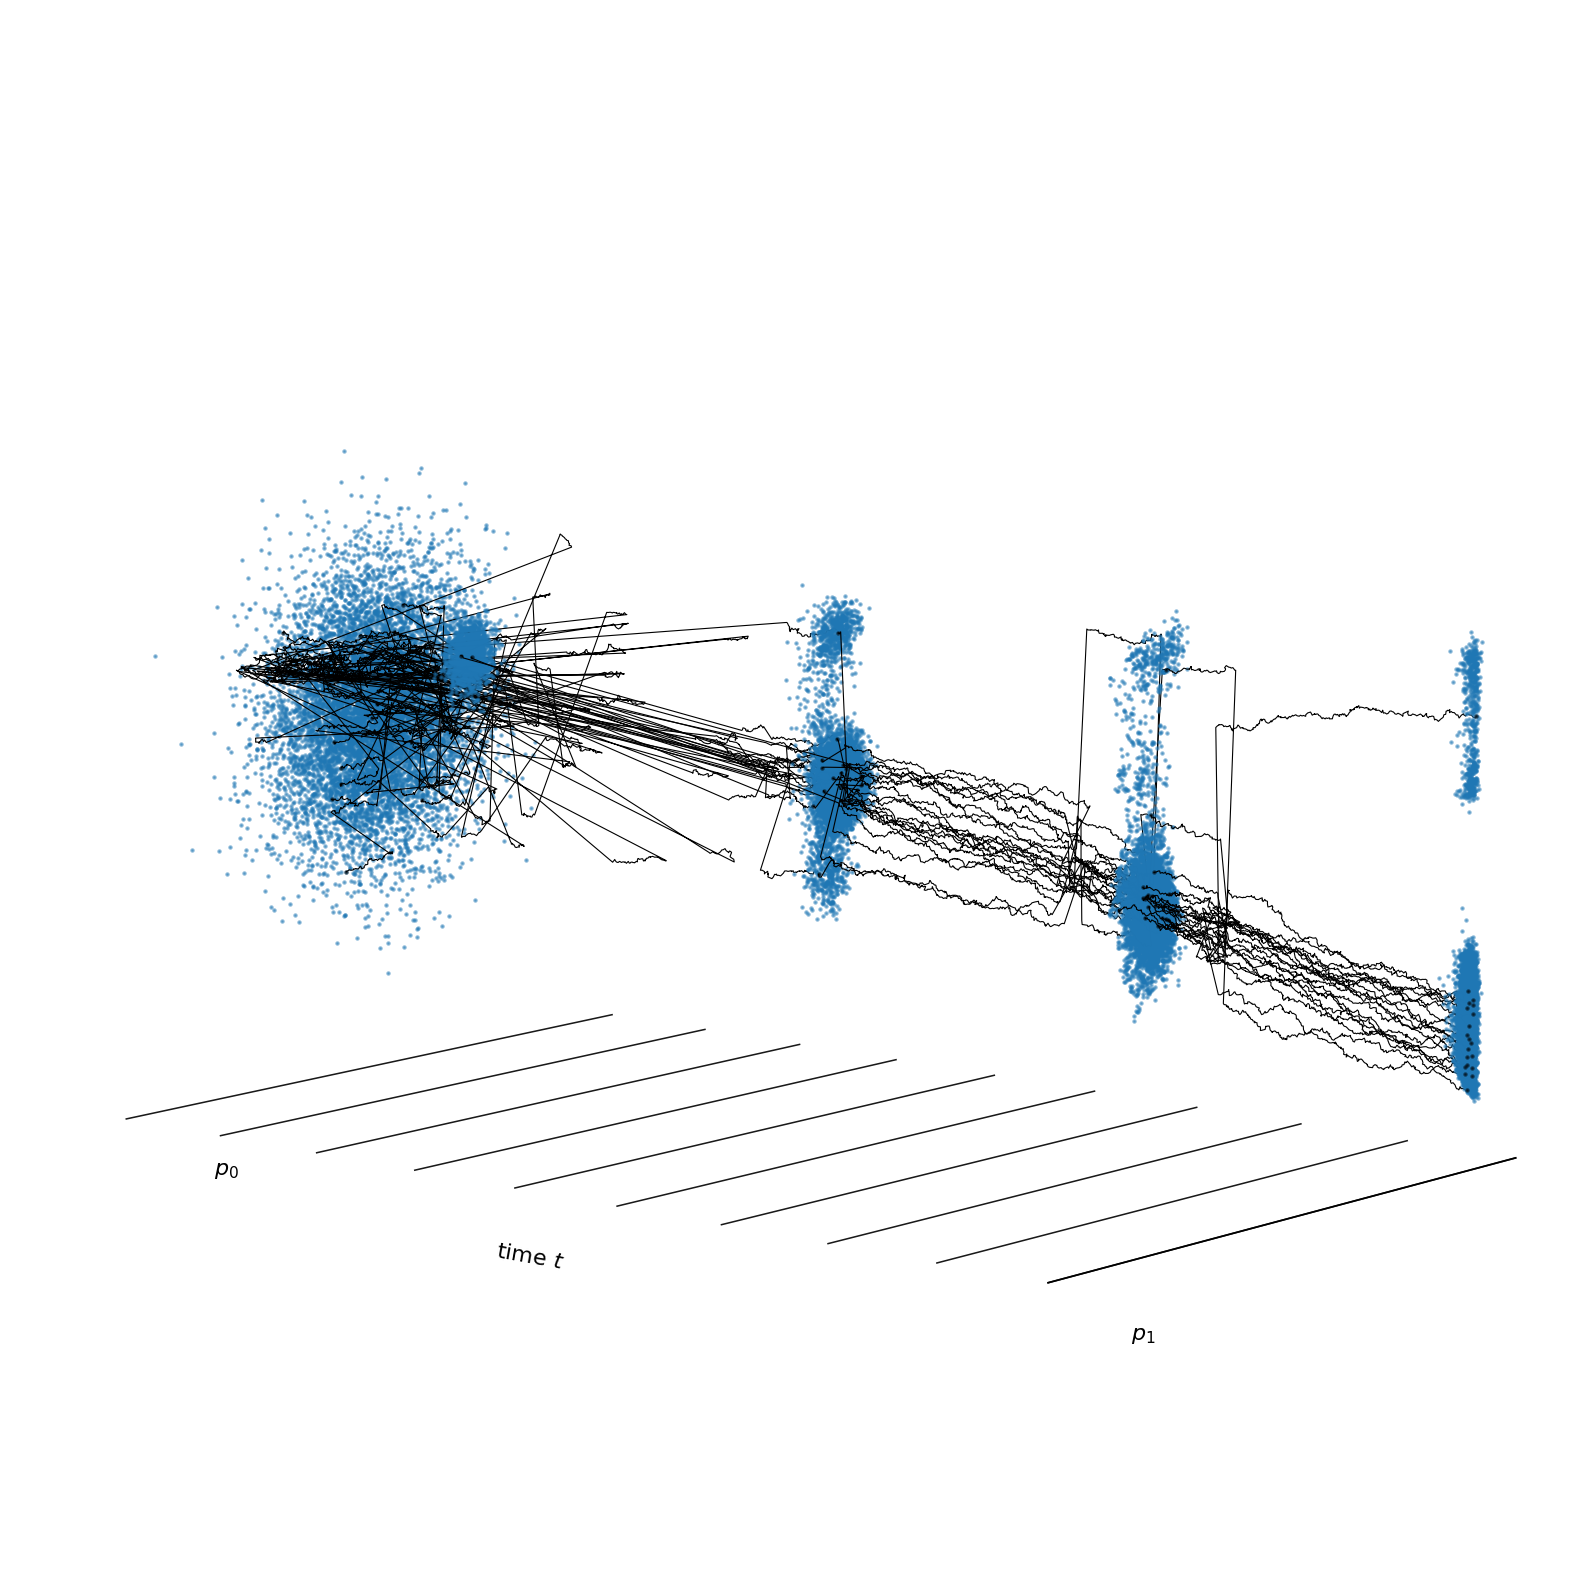

In [28]:
plot_path_trajectories(sample_history, n_frame=4, resample_history=None, experiment_id=".", name=f"alpha={names}_FKC-H", deg=-50)

Simulating ACE (Adaptive Gammas)


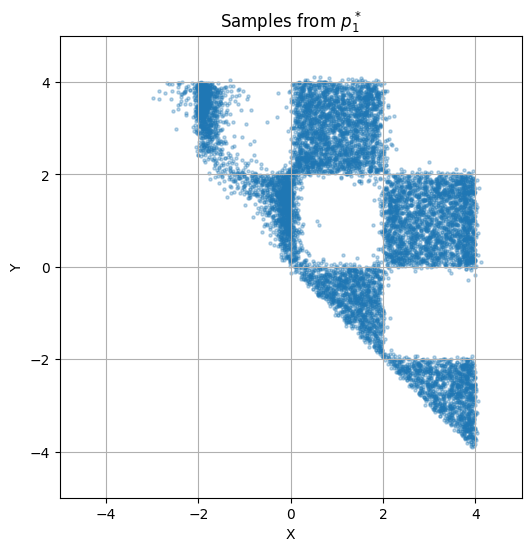

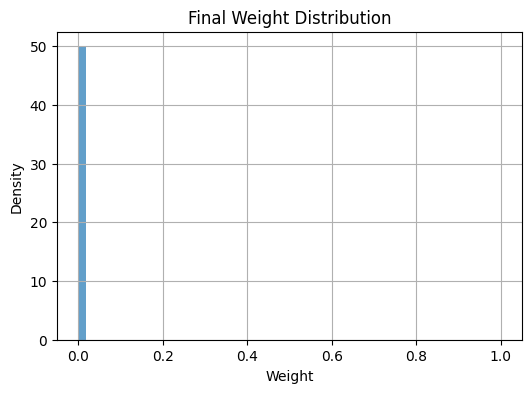

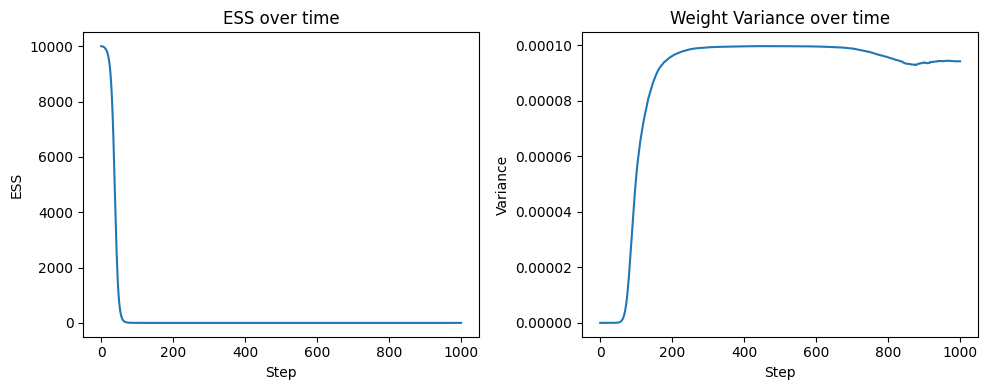

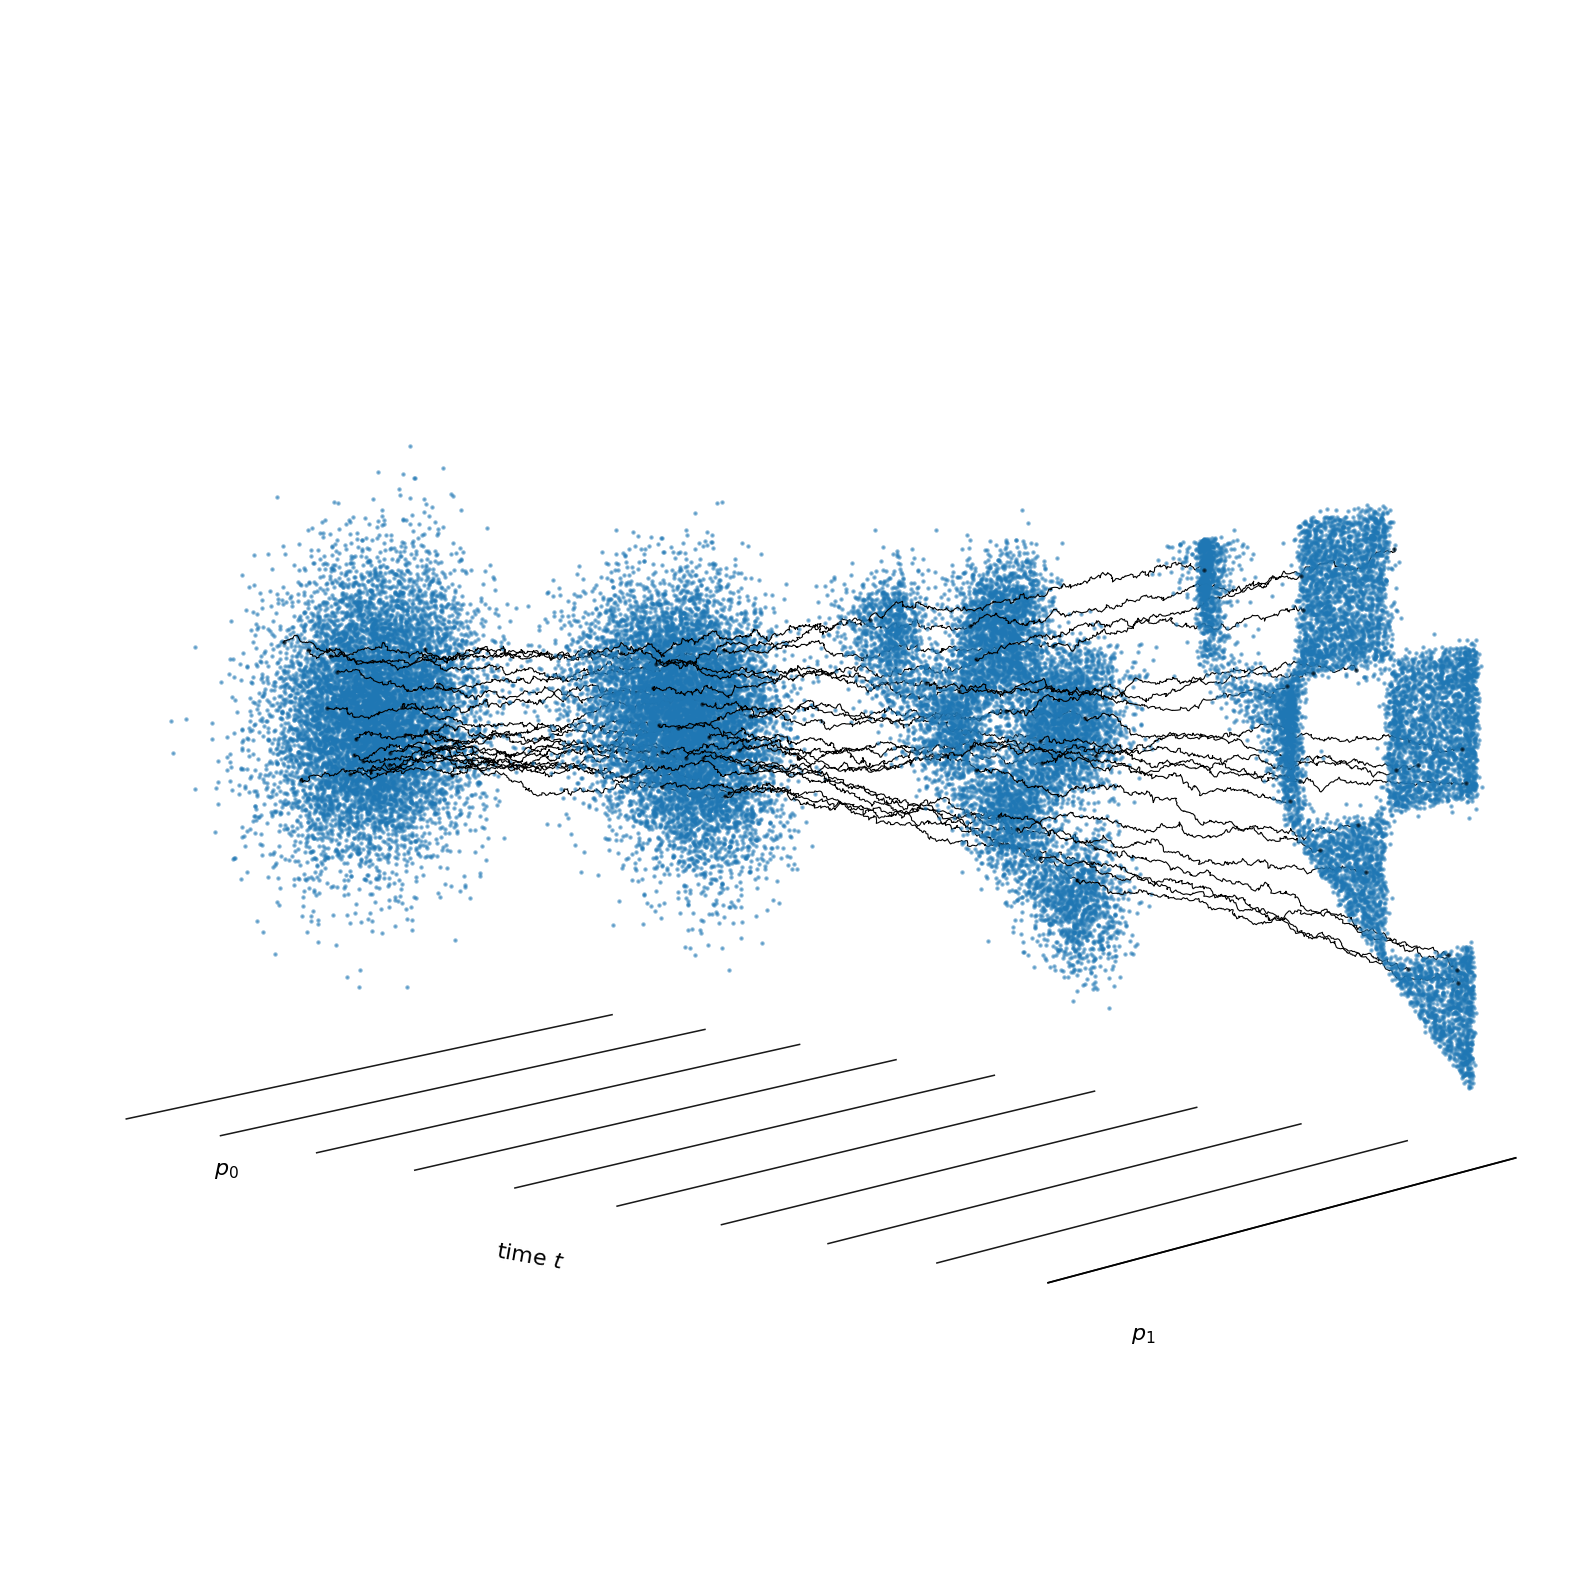

In [95]:
print("Simulating ACE (Adaptive Gammas)")
bs = 10000; n_steps =1000
Bound = 30
gamma_list = [
lambda t : torch.tensor(1), #+ torch.tensor(Bound * t * (1-t)),
lambda t : torch.tensor(1) * torch.tensor(-1), #* torch.tensor((1-2*t)**2),
lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t), #+ torch.tensor(Bound * (1-2*t)),
    lambda t: torch.zeros_like(t),# + torch.tensor(-8*t + 4),
    lambda t: torch.zeros_like(t)
]

x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values
samples, logw_final, logw_history, sample_history_adaptive, resample_history = simulate_hcg_generalized(
    x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=lambda t: torch.ones_like(t) * torch.tensor(0.5),
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
    gamma_list=gamma_list,
    d_gamma_list=d_gamma_list,
    resample=False
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_ACE")
plot_path_trajectories(sample_history_adaptive, n_frame=4, resample_history=resample_history, experiment_id=experiment_id, name=f"alpha={names}_ACE", deg=-50)

# print("Evaluating ACE")
# samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
# w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
#     torch.tensor(samples_gt), torch.tensor(samples)
# )
# print(w1, w2, mmd_rbf, total_var)


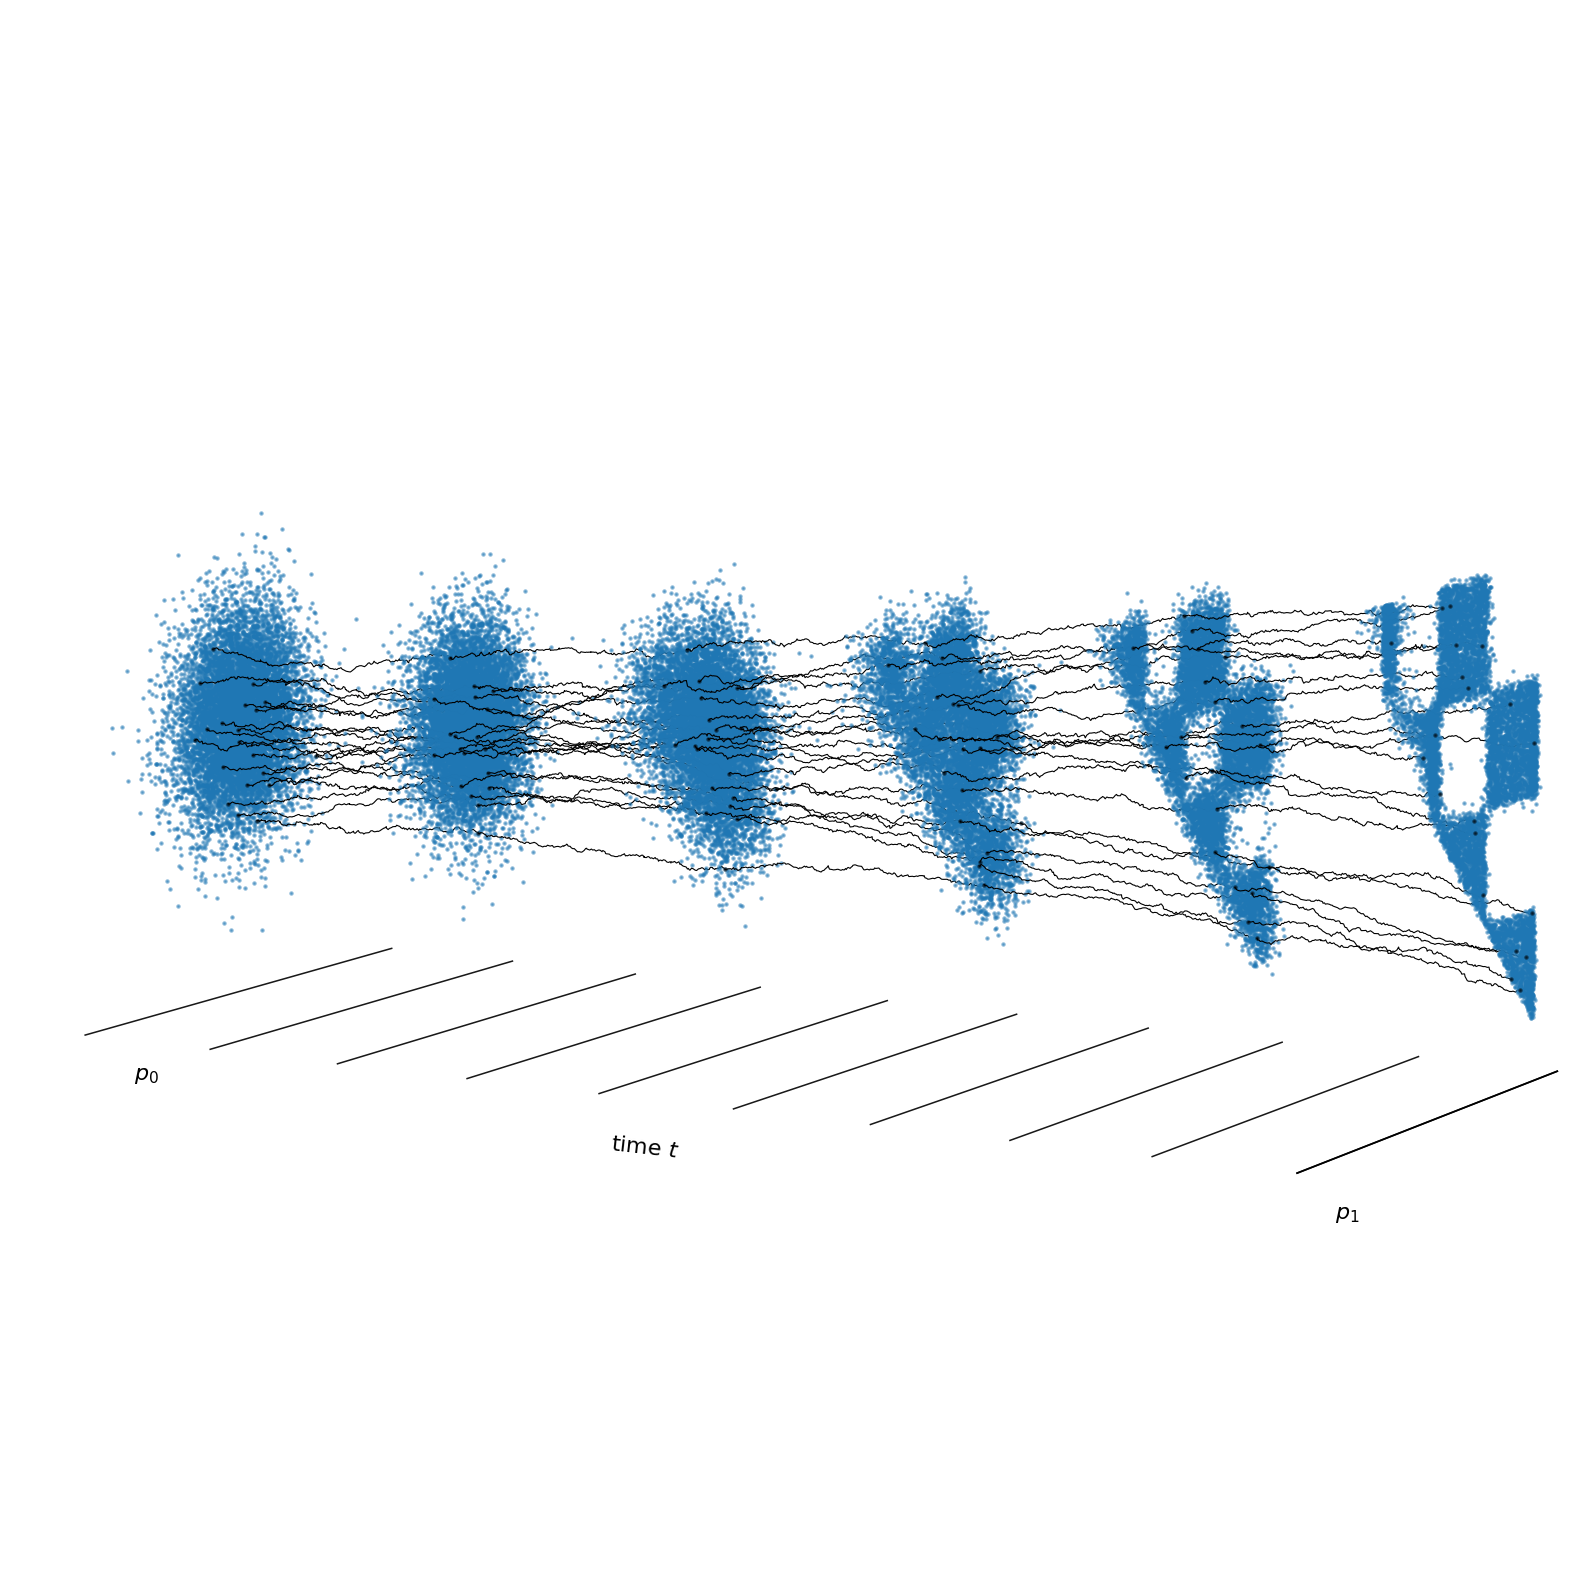

In [99]:
# plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_ACE")
plot_path_trajectories(sample_history_adaptive, n_frame=6, resample_history=resample_history, experiment_id=experiment_id, name=f"alpha={names}_ACE", deg=-60, method_figure=False, interval_d = 20)

Simulating ACE (Adaptive Gammas)


/tmp/ipykernel_2965783/572205468.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t : torch.tensor(1) * torch.tensor(-1) * torch.tensor((1-2*t)**2),
/tmp/ipykernel_2965783/572205468.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t: torch.zeros_like(t) + torch.tensor(-8*t + 4),


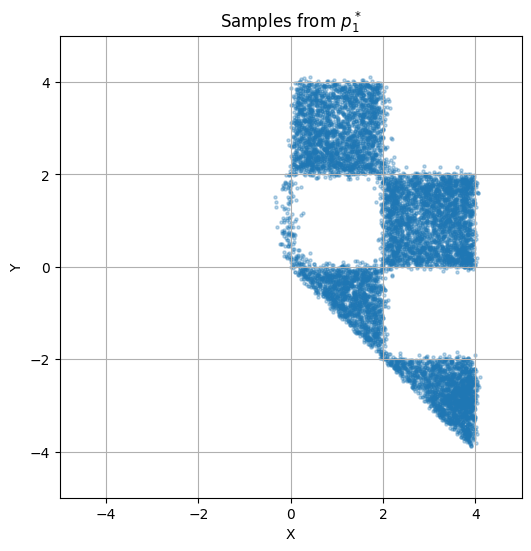

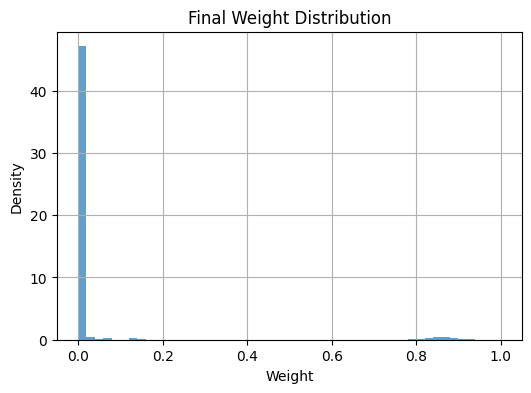

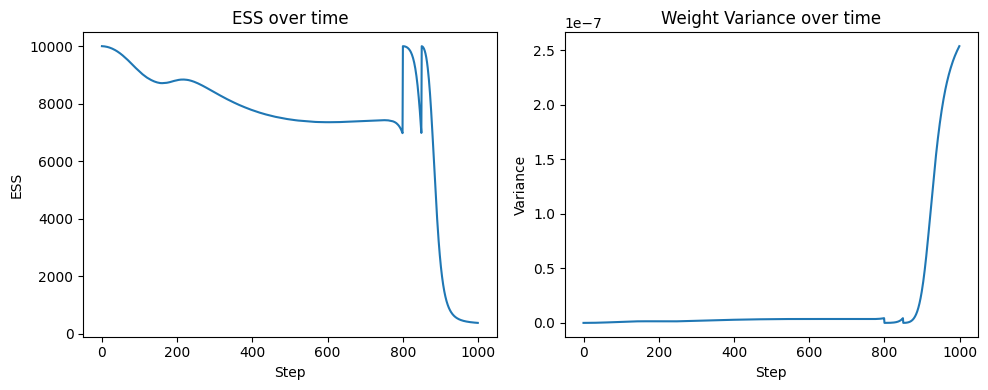

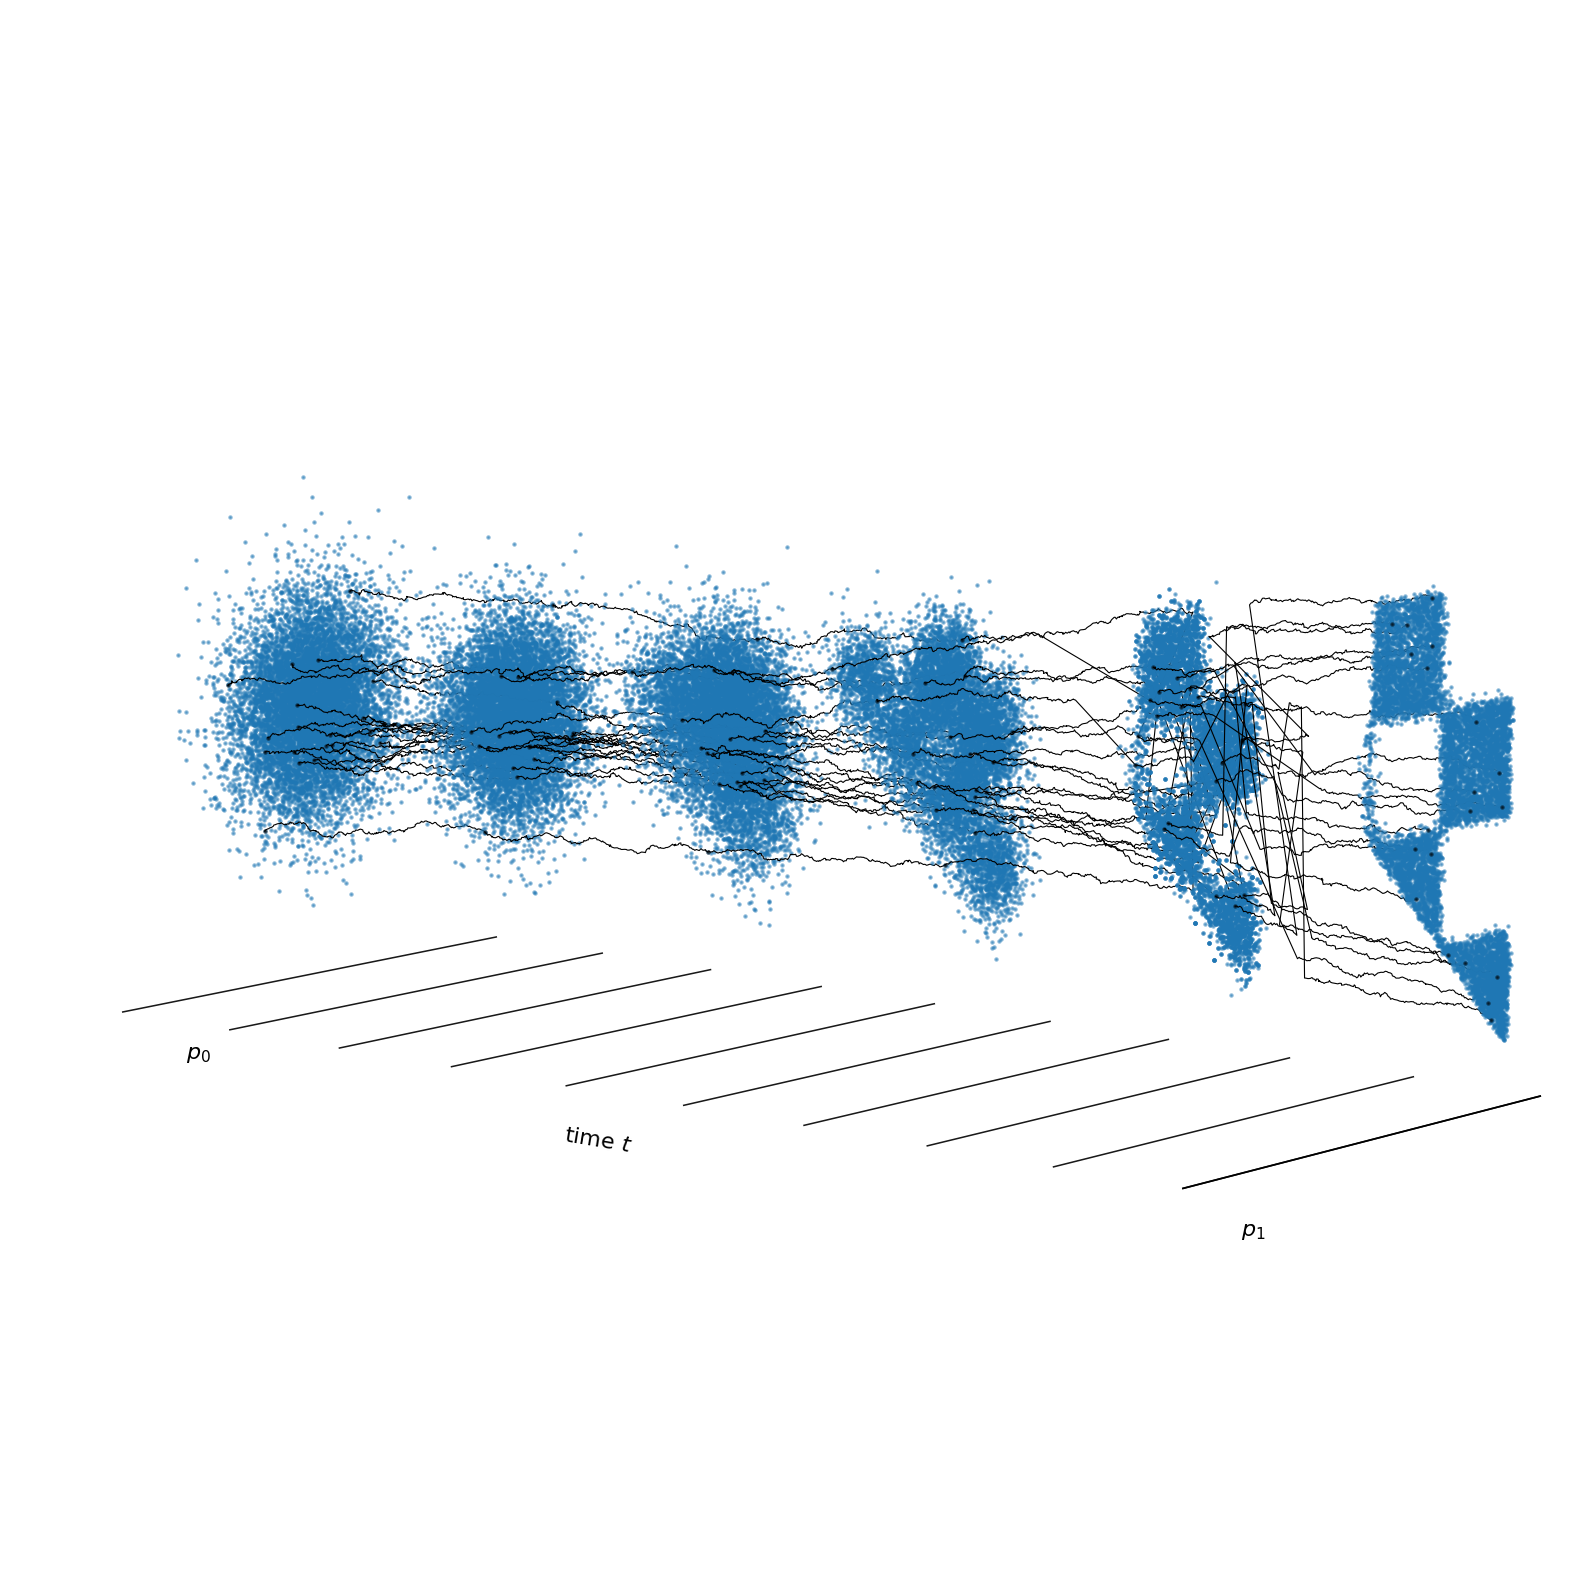

In [18]:
print("Simulating ACE (Adaptive Gammas)")
gamma_list = [
lambda t : torch.tensor(1),
lambda t : torch.tensor(1) * torch.tensor(-1) * torch.tensor((1-2*t)**2),
lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t) + torch.tensor(-8*t + 4),
    lambda t: torch.zeros_like(t)
]

x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values
samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
    gamma_list=gamma_list,
    d_gamma_list=d_gamma_list,
    resample=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_ACE")
plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_ACE", deg=-50)

# print("Evaluating ACE")
# samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
# w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
#     torch.tensor(samples_gt), torch.tensor(samples)
# )
# print(w1, w2, mmd_rbf, total_var)


['default_linear', 'custom_poly', 'default_linear']
Criterion(0.99999) = 215040.0


/tmp/ipykernel_1404454/2345898644.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t : torch.tensor(1) * torch.tensor(g).pow(t) * torch.tensor(-(1-2*t)**2),


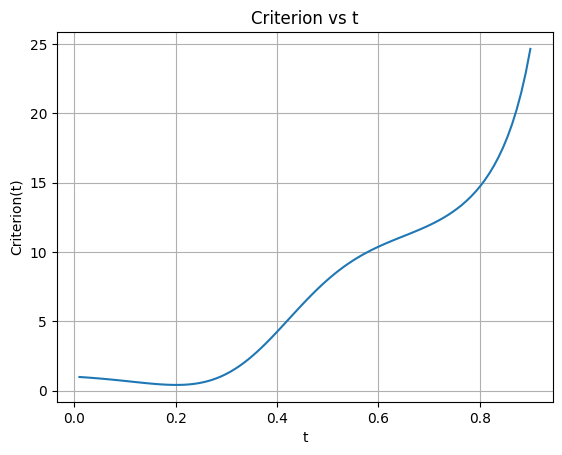

In [ ]:
print(names)
g = 8
gamma_list = [
    lambda t : torch.tensor(1),
    lambda t : torch.tensor(1) * torch.tensor(g).pow(t) * torch.tensor(-(1-2*t)**2),
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t) + torch.log(g) * torch.tensor(g).pow(t) * torch.tensor(-(1-2*t)**2) + torch.tensor(-8*t + 4) * torch.tensor(g).pow(t),
    lambda t: torch.zeros_like(t)
]
Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99999) = {Criterion(torch.tensor(0.99999)).item()}")

t = torch.linspace(0.01, 0.9, 100)
plt.plot(t.numpy(), Criterion(t).numpy())
plt.xlabel('t')
plt.ylabel('Criterion(t)')
plt.title('Criterion vs t')
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "Criterion_plot.png"))
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion = 0 at t =", t[i].item())
        break
for i in range(len(t)-1):
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion = 0 at t =", t[i].item())
        break

## Annealing

In [ ]:
g = torch.tensor(1.0) #1~8

Simulating FKC-H (Constant Gammas)


/tmp/ipykernel_1404454/661528915.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t : torch.tensor(1) * torch.tensor(-g),


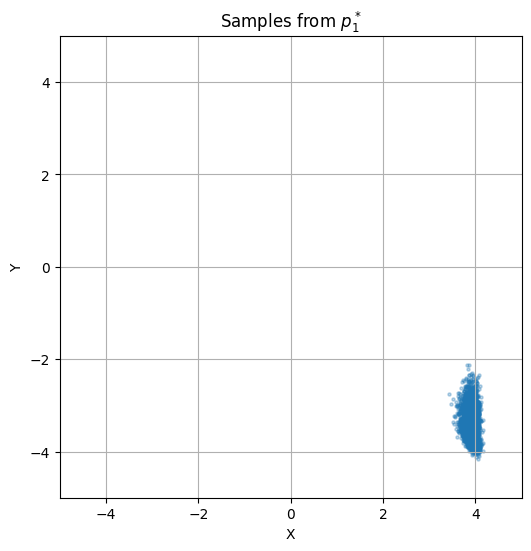

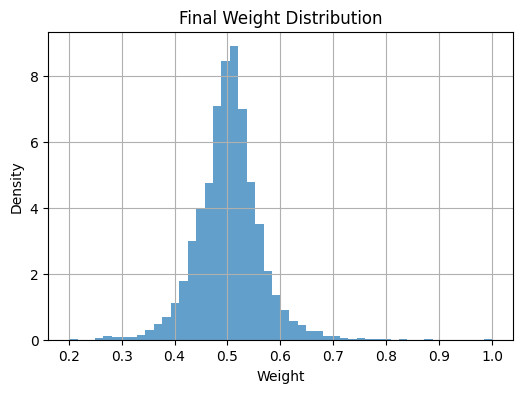

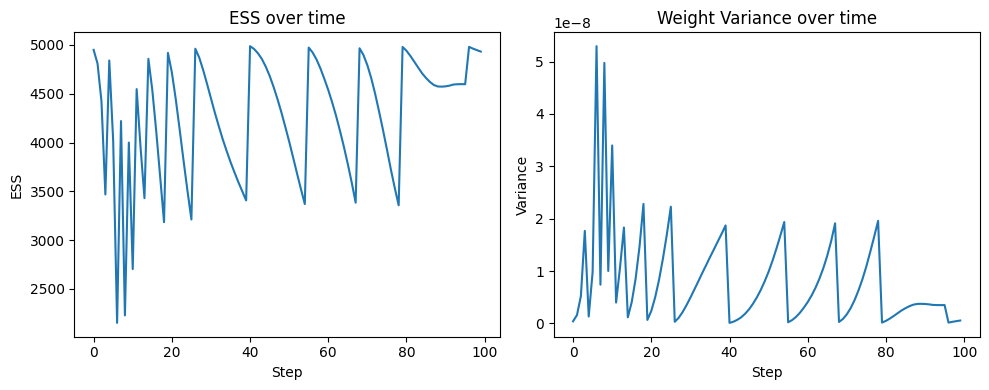

Evaluating FKC-H
4.662995001339873 5.036575576856837 2.9819347858428955 0.9854


In [ ]:
# bs = 5000; n_steps=100
print("Simulating FKC-H (Constant Gammas)")
gamma_list = [
    lambda t : torch.tensor(1),
    lambda t : torch.tensor(1) * torch.tensor(-g),
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t)
]

x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values
samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.70, print_resample_history=True,
    gamma_list=gamma_list,
    d_gamma_list=d_gamma_list,
    resample=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_FKC-H")
# plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_FKC-H", deg=-50)

# print("Evaluating FKC-H")
# samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
# w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
#     torch.tensor(samples_gt), torch.tensor(samples)
# )
# print(w1, w2, mmd_rbf, total_var)

Simulating ACE (Adaptive Gammas)


/tmp/ipykernel_2965783/373728396.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t : torch.tensor(1) * torch.tensor(g).pow(t) * torch.tensor(-(1-2*t)**2),
/tmp/ipykernel_2965783/373728396.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t: torch.zeros_like(t) + torch.log(g) * torch.tensor(g).pow(t) * torch.tensor(-(1-2*t)**2) + torch.tensor(-8*t + 4) * torch.tensor(g).pow(t),


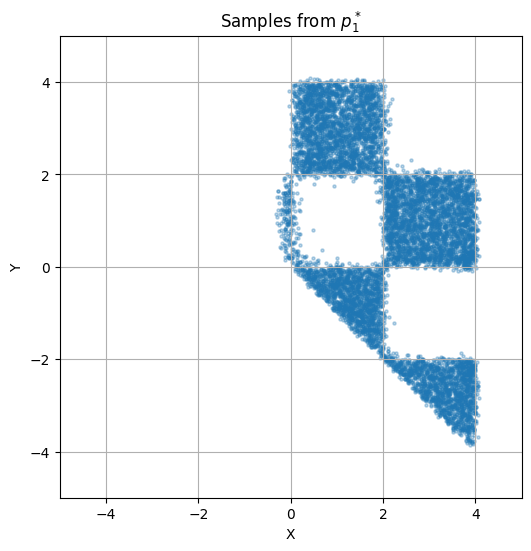

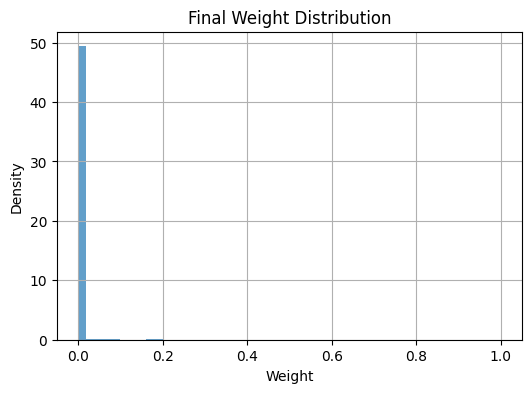

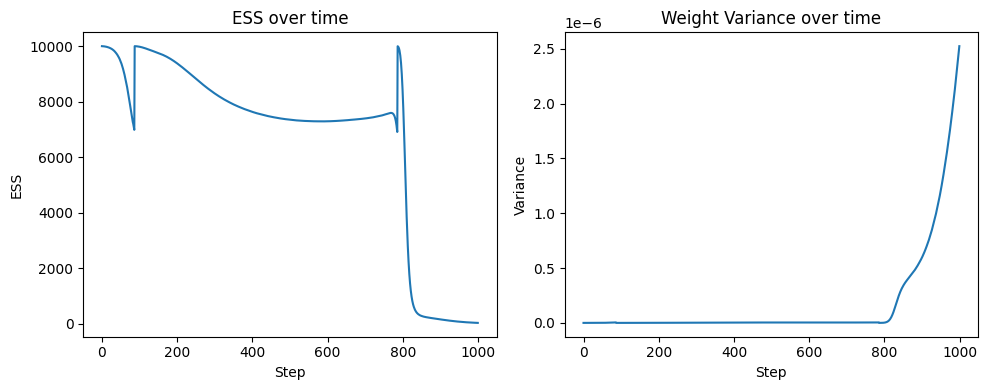

In [22]:
print("Simulating ACE (Adaptive Gammas)")
gamma_list = [
    lambda t : torch.tensor(1),
    lambda t : torch.tensor(1) * torch.tensor(g).pow(t) * torch.tensor(-(1-2*t)**2),
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t) + torch.log(g) * torch.tensor(g).pow(t) * torch.tensor(-(1-2*t)**2) + torch.tensor(-8*t + 4) * torch.tensor(g).pow(t),
    lambda t: torch.zeros_like(t)
]

x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values
samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
    gamma_list=gamma_list,
    d_gamma_list=d_gamma_list,
    resample=True, t_max = 0.8
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_ACE")
# plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_ACE", deg=-50)

# print("Evaluating ACE")
# samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
# w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
#     torch.tensor(samples_gt), torch.tensor(samples)
# )
# print(w1, w2, mmd_rbf, total_var)


# Experiment 2. Annealing

In [23]:
names = ["sigmoid", "default_linear", "default_linear"]
subexperiment_id = f"{names}"
experiment_id = f"{top_experiment_id}/{subexperiment_id}"
if not os.path.exists(experiment_id):
    os.makedirs(experiment_id)

u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={names[0]}.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={names[0]}.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={names[2]}.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={names[2]}.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={names[1]}.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={names[1]}.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
def sigma_fn(t): return 0.5 * torch.ones_like(t)

v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ]
s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ]
proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ]
emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ]

print("Models loaded.")

Models loaded.


In [ ]:
seeds=[0,1,2,3,4]
# gs = [-1.0, -1.2, -1.4, -1.6, -2, -4, -6]
gs = [-1.4]
Bump = 10
# bs = 5000; n_steps=100
print(f"bs = {bs}, n_steps = {n_steps}")
for g in gs:
    results = []
    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        # samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
        print(f"Seed set to {seed}")

        print(f"Annealed Temperature = {g}")
        print("Simulating NR")
        gamma_list = [
            lambda t : torch.tensor(1),
            lambda t : torch.tensor(g),
            lambda t : torch.tensor(1)
        ]
        d_gamma_list = [
            lambda t: torch.zeros_like(t),
            lambda t: torch.zeros_like(t),
            lambda t: torch.zeros_like(t)
        ]
        
        x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
        A, B = 1, 1  # Conditioning values
        samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
            x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
            v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
            t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
            gamma_list=gamma_list,
            d_gamma_list=d_gamma_list,
            resample=False
        )
        samples = samples.cpu().numpy()
        plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_NR_seed{seed}_g{g}")
        plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_NR_seed{seed}_g{g}", deg=-50)
        plt.close(); clear_output()
    
        # print("Evaluating NR")
        # w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
        #     torch.tensor(samples_gt), torch.tensor(samples)
        # )
        # results.append([seed, "NR", w1, w2, mmd_rbf, total_var])

        print("Simulating FKC-H (Constant Gammas)")
        gamma_list = [
            lambda t : torch.tensor(1),
            lambda t : torch.tensor(g),
            lambda t : torch.tensor(1)
        ]
        d_gamma_list = [
            lambda t: torch.zeros_like(t),
            lambda t: torch.zeros_like(t),
            lambda t: torch.zeros_like(t)
        ]

        x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
        A, B = 1, 1  # Conditioning values
        samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
            x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
            v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
            t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
            gamma_list=gamma_list,
            d_gamma_list=d_gamma_list,
            resample=True
        )
        samples = samples.cpu().numpy()
        plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_FKC-H_seed{seed}_g{g}")
        plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_FKC-H_seed{seed}_g{g}", deg=-50)
        plt.close(); clear_output()

        # print("Evaluating FKC-H")
        # w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
        #     torch.tensor(samples_gt), torch.tensor(samples)
        # )
        # results.append([seed, "FKC-H", w1, w2, mmd_rbf, total_var])

        print("Simulating ACE (Adaptive Gammas)")
        gamma_list = [
            lambda t : torch.tensor(1),
            lambda t : torch.tensor(g),
            lambda t : torch.tensor(1) + torch.tensor(Bump* t * (1-t))
        ]
        d_gamma_list = [
            lambda t: torch.zeros_like(t),
            lambda t: torch.zeros_like(t),
            lambda t: torch.zeros_like(t) + torch.tensor(Bump* (1 - 2*t))
        ]

        x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
        A, B = 1, 1  # Conditioning values
        samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
            x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
            v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
            t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
            gamma_list=gamma_list,
            d_gamma_list=d_gamma_list,
            resample=True
        )
        samples = samples.cpu().numpy()
        plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_ACE_seed{seed}_g{g}")
        plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_ACE_seed{seed}_g{g}", deg=-50)
        plt.close(); clear_output()

        # print("Evaluating ACE")
        # w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
        #     torch.tensor(samples_gt), torch.tensor(samples)
        # )
        # results.append([seed, "ACE", w1, w2, mmd_rbf, total_var])

    df = pd.DataFrame(results, columns=["seed", "method", "W1", "W2", "MMD_RBF", "Total Var."])
    df.to_csv(f"{experiment_id}/experiment_results_numseeds{len(seeds)}_bs{bs}_n_steps{n_steps}_g{g}.csv", index=False)
    print(df)

['sigmoid', 'default_linear', 'default_linear']
Criterion(0.99999) = -3989157888.0


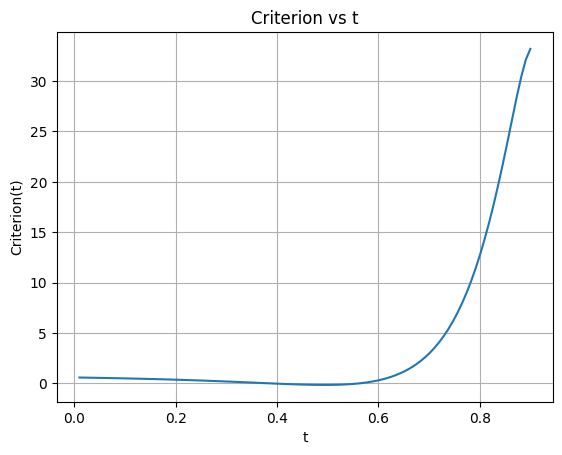

Criterion = 0 at t = 0.38757574558258057
Criterion = 0 at t = 0.5583838224411011


In [36]:
print(names)
g = -1.4
gamma_list = [
    lambda t : torch.tensor(1),
    lambda t : torch.tensor(g),
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t)
]
Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99999) = {Criterion(torch.tensor(0.99999)).item()}")

t = torch.linspace(0.01, 0.9, 100)
plt.plot(t.numpy(), Criterion(t).numpy())
plt.xlabel('t')
plt.ylabel('Criterion(t)')
plt.title('Criterion vs t')
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "Criterion_plot.png"))
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion = 0 at t =", t[i].item())
        break
for i in range(len(t)-1):
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion = 0 at t =", t[i].item())
        break

['sigmoid', 'default_linear', 'default_linear']
Criterion(0.99) = -8794.99609375


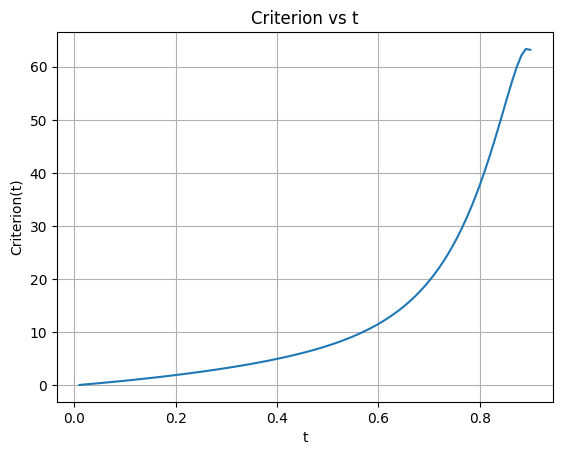

In [ ]:
print(names)
g = -2
Bump = 10
gamma_list = [
    lambda t : torch.tensor(1) ,
    lambda t : torch.tensor(g),
    lambda t : torch.tensor(1) + Bump * t * (1-t)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t) ,
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t) + Bump * (1 - 2*t)
]
Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99) = {Criterion(torch.tensor(0.99)).item()}")

t = torch.linspace(0.01, 0.9, 100)
plt.plot(t.numpy(), Criterion(t).numpy())
plt.xlabel('t')
plt.ylabel('Criterion(t)')
plt.title('Criterion vs t')
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "Criterion_plot.png"))
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion = 0 at t =", t[i].item())
        break
for i in range(len(t)-1):
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion = 0 at t =", t[i].item())
        break

# Experiment 3. Common Schedules

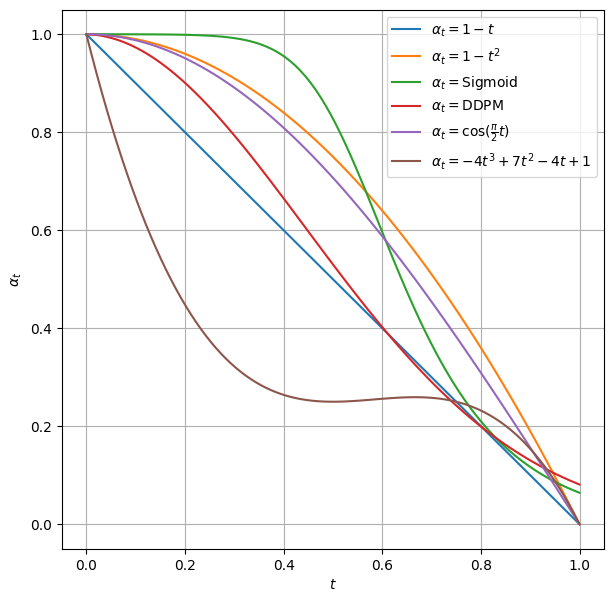

In [55]:
import torch
import itertools
import json
import matplotlib.pyplot as plt
import os

experiment_id = "."

def load_interpolants_from_json_alpha_only(path):
    with open(path, "r") as f:
        interpolants_raw = json.load(f)

    interpolants = {}
    for name, funcs in interpolants_raw.items():
        alpha_t = eval(funcs["alpha_t"], {"torch": torch})
        interpolants[name] = alpha_t
    return interpolants

# Load
interpolants = load_interpolants_from_json_alpha_only("interpolant_schedules.json")
names = list(interpolants.keys())

t = torch.linspace(0.0, 1.0, 100)

name_eq = {
    "custom_poly": r"$\alpha_t = -4t^3+7t^2-4t+1$",
    "ddpm_linear": r"$\alpha_t = \text{DDPM}$",
    "1-t**2": r"$\alpha_t = 1-t^2$",
    "sigmoid": r"$\alpha_t = \text{Sigmoid}$",
    "default_linear": r"$\alpha_t = 1-t$",
    "cos_t": r"$\alpha_t=\cos(\frac{\pi}{2}t)$"
}


plt.figure(figsize=(7, 7)) 
for name in interpolants.keys():
    plt.plot(t.numpy(), interpolants[name](t).numpy(), label=name_eq[name])
    # print(name, interpolant_schedules[name].alpha_t(0), interpolant_schedules[name].beta_t(0), interpolant_schedules[name].d_alpha_t(0), interpolant_schedules[name].d_beta_t(0))
plt.xlabel(r'$t$')
plt.ylabel(r'$\alpha_t$')
# plt.title(r'$\alpha_t$ vs $t$ Graph for Common Noise Schedules')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "alpha_t_plot_common_schedules.png"))
plt.show()

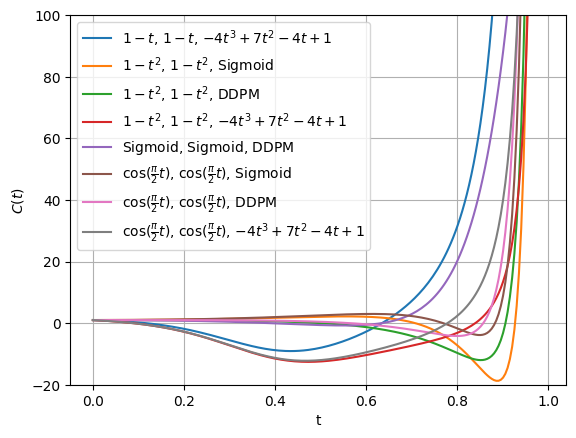

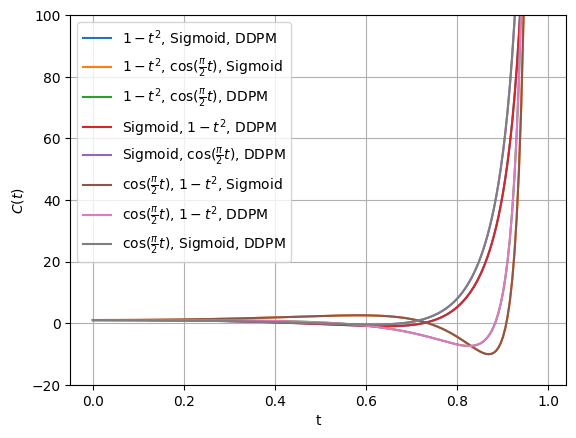

Valid pairs:
['default_linear', 'default_linear', 'custom_poly']
['1-t**2', '1-t**2', 'sigmoid']
['1-t**2', '1-t**2', 'ddpm_linear']
['1-t**2', '1-t**2', 'custom_poly']
['sigmoid', 'sigmoid', 'ddpm_linear']
['cos_t', 'cos_t', 'sigmoid']
['cos_t', 'cos_t', 'ddpm_linear']
['cos_t', 'cos_t', 'custom_poly']

Valid triples:
['1-t**2', 'sigmoid', 'ddpm_linear']
['1-t**2', 'cos_t', 'sigmoid']
['1-t**2', 'cos_t', 'ddpm_linear']
['sigmoid', '1-t**2', 'ddpm_linear']
['sigmoid', 'cos_t', 'ddpm_linear']
['cos_t', '1-t**2', 'sigmoid']
['cos_t', '1-t**2', 'ddpm_linear']
['cos_t', 'sigmoid', 'ddpm_linear']


In [45]:
def check_condition(alpha_funcs, g=1.0, n_grid=200, Bump = 0.0):
    """Check sign conditions for [a1, a2] or [a1, a2, a3]."""
    ts = torch.linspace(0.0, 0.99, n_grid)

    alphas = [f(ts) for f in alpha_funcs]
    Bumps = torch.tensor([Bump * t * (1-t) for t in ts])
    if len(alpha_funcs) == 2:
        C = 2 / (alphas[0]**2 + 1e-12) - g / (alphas[1]**2 + 1e-12) + Bumps / (alphas[0]**2 + 1e-12)
    elif len(alpha_funcs) == 3:
        C = 1 / (alphas[0]**2 + 1e-12) + 1 / (alphas[1]**2 + 1e-12) - g / (alphas[2]**2 + 1e-12) + Bumps / (alphas[0]**2 + 1e-12)
    else:
        raise ValueError("Only supports 2 or 3 schedules")

    return (C[0] > 0) and (C[-1] > 0) and (C.min() < 0), ts, C


name_eq_plot = {
    "custom_poly": r"$-4t^3+7t^2-4t+1$",
    "ddpm_linear": r"$\text{DDPM}$",
    "1-t**2": r"$1-t^2$",
    "sigmoid": r"$\text{Sigmoid}$",
    "default_linear": r"$1-t$",
    "cos_t": r"$\cos(\frac{\pi}{2}t)$"
}


def find_valid_combinations(interpolants, g=1.0):
    valid_pairs, valid_triples = [], []

    for a1, a2 in itertools.permutations(interpolants, 2):
        # if a1 == "custom_poly" or a2 =="custom_poly":
            # continue
        valid, t, C = check_condition([interpolants[a1], interpolants[a2]], g=g)
        if valid:
            valid_pairs.append([a1, a1, a2])
        # ask whether to plot or pass
            # user_input = input(f"{[a1, a1, a2]} is a valid example. Should I plot? [Y/N]")
            # from IPython.display import clear_output; clear_output()
            # if user_input == "Y":
            plt.ylim((-20,100))
            plt.grid(True)
            plt.plot(t.numpy(), C.numpy(), label=f'{name_eq_plot[a1]}, {name_eq_plot[a1]}, {name_eq_plot[a2]}')
            plt.legend()
    plt.xlabel('t')
    plt.ylabel(r"$C(t)$")
    plt.savefig(os.path.join(experiment_id, f"Criterion_plot_a1a1a2_no_bump.png"))
    plt.show()
    plt.close()

    for a1, a2, a3 in itertools.permutations(interpolants, 3):
        if "custom_poly" in [a1, a2, a3]:
            continue
        
        valid, t, C = check_condition([interpolants[a1], interpolants[a2], interpolants[a3]], g=g)
        if valid:
            valid_triples.append([a1, a2, a3])
            plt.ylim((-20,100))
            plt.grid(True)
            plt.plot(t.numpy(), C.numpy(), label=f'{name_eq_plot[a1]}, {name_eq_plot[a2]}, {name_eq_plot[a3]}')
            plt.legend()
    plt.xlabel('t')
    plt.ylabel(r"$C(t)$")
    plt.savefig(os.path.join(experiment_id, f"Criterion_plot_a1a2a3_no_bump.png"))
    plt.show()
    plt.close()

    return valid_pairs, valid_triples

pairs, triples = find_valid_combinations(interpolants, g=1.0)

print("Valid pairs:")
for p in pairs:
    print(p)
print("\nValid triples:")
for t in triples:
    print(t)

names_invalid_common_cases = ["default_linear", "default_linear", ]

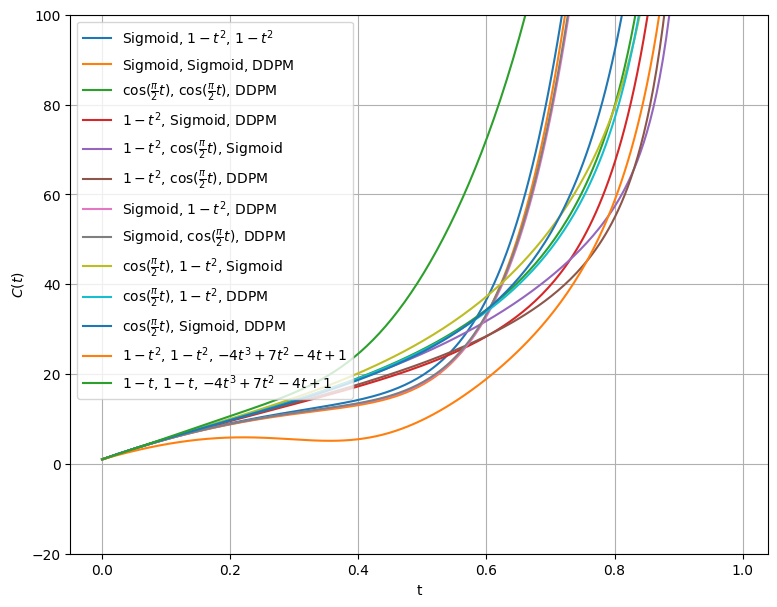

In [68]:
names_invalid_common_cases = [
# ['1-t**2', '1-t**2', 'sigmoid'],
# ['1-t**2', '1-t**2', 'ddpm_linear'],
['sigmoid', '1-t**2', '1-t**2'],
['sigmoid', 'sigmoid', 'ddpm_linear'],
# ['cos_t', 'cos_t', 'sigmoid'],
['cos_t', 'cos_t', 'ddpm_linear'],
# ['cos_t', 'cos_t', 'custom_poly'],
['1-t**2', 'sigmoid', 'ddpm_linear'],
['1-t**2', 'cos_t', 'sigmoid'],
['1-t**2', 'cos_t', 'ddpm_linear'],
['sigmoid', '1-t**2', 'ddpm_linear'],
['sigmoid', 'cos_t', 'ddpm_linear'],
['cos_t', '1-t**2', 'sigmoid'],
['cos_t', '1-t**2', 'ddpm_linear'],
['cos_t', 'sigmoid', 'ddpm_linear'],
['1-t**2', '1-t**2', 'custom_poly'],
['default_linear', 'default_linear', 'custom_poly']
]

g = 1.0
plt.figure(figsize=(9,7))
for names in names_invalid_common_cases:
    a1, a2, a3 = names
    valid, t, C = check_condition([interpolants[a1], interpolants[a2], interpolants[a3]], g=g, Bump=50)
    plt.ylim((-20,100))
    plt.grid(True)
    plt.plot(t.numpy(), C.numpy(), label=f'{name_eq_plot[a1]}, {name_eq_plot[a2]}, {name_eq_plot[a3]}')
    plt.legend()
plt.xlabel('t')
plt.ylabel(r"$C(t)$")
plt.savefig(os.path.join(experiment_id, f"Criterion_plot_a1a2a3_no_bump.png"))
plt.show()
plt.close()

In [119]:
import torch
import itertools
import json
import matplotlib.pyplot as plt

def load_interpolants_from_json(path):
    with open(path, "r") as f:
        interpolants_raw = json.load(f)

    interpolants = {}
    for name, funcs in interpolants_raw.items():
        alpha_t = eval(funcs["alpha_t"], {"torch": torch})
        interpolants[name] = alpha_t
    return interpolants

# Load schedules
interpolants = load_interpolants_from_json("interpolant_schedules.json")

def check_condition(alpha_funcs, g=1.0, n_grid=200):
    """Check sign conditions for 2 or 3 schedules and return C(t)."""
    t = torch.linspace(0, 0.9999, n_grid)
    alphas = [f(t) for f in alpha_funcs]

    if len(alpha_funcs) == 2:
        C = 1 / (alphas[0]**2 + 1e-12) - g / (alphas[1]**2 + 1e-12)
    elif len(alpha_funcs) == 3:
        C = 1 / (alphas[0]**2 + 1e-12) - g / (alphas[1]**2 + 1e-12) + 1 / (alphas[2]**2 + 1e-12)
    else:
        raise ValueError("Only supports 2 or 3 schedules")

    valid = (C.min() < 0)
    return valid, t, C

def find_and_plot_combinations(interpolants, g=1.0):
    names = list(interpolants.keys())

    # For storing results
    valid_pairs, valid_triples = [], []

    # Check pairs
    for a1, a2 in itertools.permutations(names, 2):
        valid, t, C = check_condition([interpolants[a1], interpolants[a2]], g=g)
        if valid:
            valid_pairs.append([a1, a2])
            plt.figure(figsize=(5,3))
            plt.plot(t.numpy(), C.numpy(), label=f"C(t) = 1/{a1}^2 - g/{a2}^2")
            plt.title(f"Valid Pair: [{a1}, {a2}]")
            plt.axhline(0, color='black', linestyle='--')
            plt.xlabel("t")
            plt.ylabel("C(t)")
            plt.legend()
            plt.tight_layout()
            plt.show()

    # Check triples
    for a1, a2, a3 in itertools.permutations(names, 3):
        valid, t, C = check_condition([interpolants[a1], interpolants[a2], interpolants[a3]], g=g)
        if valid:
            valid_triples.append([a1, a2, a3])
            plt.figure(figsize=(5,3))
            plt.plot(t.numpy(), C.numpy(), label=f"C(t) = 1/{a1}^2 - g/{a2}^2 + 1/{a3}^2")
            plt.title(f"Valid Triple: [{a1}, {a2}, {a3}]")
            plt.axhline(0, color='black', linestyle='--')
            plt.xlabel("t")
            plt.ylabel("C(t)")
            # plt.ylim((-1,1))
            plt.legend()
            plt.tight_layout()
            plt.show()

    return valid_pairs, valid_triples

# pairs, triples = find_and_plot_combinations(interpolants, g=1.0)

print("Valid pairs:", pairs)
print("Valid triples:", triples)


Valid pairs: [['sigmoid', 'ddpm_linear']]
Valid triples: [['custom_poly', 'ddpm_linear', '1-t**2'], ['custom_poly', 'ddpm_linear', 'denovo'], ['custom_poly', 'sigmoid', '1-t**2'], ['custom_poly', 'sigmoid', 'denovo'], ['ddpm_linear', 'custom_poly', 'default_linear'], ['ddpm_linear', 'custom_poly', 'cos_t'], ['1-t**2', 'custom_poly', 'denovo'], ['1-t**2', 'custom_poly', 'default_linear'], ['1-t**2', 'custom_poly', 'cos_t'], ['1-t**2', 'ddpm_linear', 'custom_poly'], ['1-t**2', 'ddpm_linear', 'denovo'], ['1-t**2', 'ddpm_linear', 'sigmoid'], ['1-t**2', 'ddpm_linear', 'cos_t'], ['1-t**2', 'sigmoid', 'custom_poly'], ['1-t**2', 'sigmoid', 'denovo'], ['1-t**2', 'sigmoid', 'cos_t'], ['denovo', 'custom_poly', '1-t**2'], ['denovo', 'custom_poly', 'default_linear'], ['denovo', 'custom_poly', 'cos_t'], ['denovo', 'ddpm_linear', 'custom_poly'], ['denovo', 'ddpm_linear', '1-t**2'], ['denovo', 'ddpm_linear', 'sigmoid'], ['denovo', 'ddpm_linear', 'cos_t'], ['denovo', 'sigmoid', 'custom_poly'], ['denovo

In [69]:
for names in triples:
    print(names)
    subexperiment_id = f"{names}"
    experiment_id = f"{top_experiment_id}/{subexperiment_id}_Finding_Common_Schedules"
    if not os.path.exists(experiment_id):
        os.makedirs(experiment_id)

    u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={names[0]}.pth")); u_model1.eval()
    s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={names[0]}.pth")); s_model1.eval()
    u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={names[2]}.pth")); u_model2.eval()
    s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={names[2]}.pth")); s_model2.eval()
    u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={names[1]}.pth")); u_model3.eval()
    s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={names[1]}.pth")); s_model3.eval()

    def v1_fn(x, t, A): return u_model1(x, t, A)
    def s1_fn(x, t, A): return s_model1(x, t, A)
    def v2_fn(x, t): return u_model3(x, t)
    def s2_fn(x, t): return s_model3(x, t)
    def v3_fn(z, t, B): return u_model2(z, t, B)
    def s3_fn(z, t, B): return s_model2(z, t, B)
    def sigma_fn(t): return 0.5 * torch.ones_like(t)

    v_fn_list=[
            lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
            lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
            lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
        ]
    s_fn_list=[
            lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
            lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
            lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
        ]
    proj_list=[
            lambda z: z[:, :1],    # project to X 
            lambda z: z[:, :1],    # project to X
            lambda z: z            # identity for Z
        ]
    emb_list=[
            lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
            lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
            lambda z: z  # identity
        ]

    print("Models loaded.")

    bs = 5000; n_steps=100
    seeds = [0]
    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
        print(f"Seed set to {seed}")

        print("Simulating FKC-H (Constant Gammas)")
        gamma_list = [
            lambda t : torch.tensor(1),
            lambda t : torch.tensor(1) * torch.tensor(-1) ,
            lambda t : torch.tensor(1)
        ]
        d_gamma_list = [
            lambda t: torch.zeros_like(t),
            lambda t: torch.zeros_like(t),
            lambda t: torch.zeros_like(t)
        ]

        x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
        A, B = 1, 1  # Conditioning values
        samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
            x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
            v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
            t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
            gamma_list=gamma_list,
            d_gamma_list=d_gamma_list,
            resample=True
        )
        samples = samples.cpu().numpy()
        plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_FKC-H_seed{seed}")
        plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_FKC-H_seed{seed}", deg=-50)
        plt.close(); clear_output()

In [118]:
# names = ["cos_t", "sigmoid", "1-t**2"]
# names = ["1-t**2", "sigmoid", "cos_t"] # (0.7316, 0.9025)
# names = ["1-t**2", "sigmoid", "1-t**2"] # (0.703, 0.921)
names = ["default_linear", "custom_poly", "default_linear"] #-> Bump = 14 works
names = ["sigmoid", "ddpm_linear", "sigmoid"] # -> Bump = 5 works
# names = ["1-t**2", "default_linear", "1-t**2"]

print(names)
subexperiment_id = f"{names}"
experiment_id = f"{top_experiment_id}/{subexperiment_id}_Common_Schedules_with_Collapse"
if not os.path.exists(experiment_id):
    os.makedirs(experiment_id)

Bump = 0
gamma_list = [
    lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),
    lambda t : torch.tensor(1) * torch.tensor(-1) ,
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t) + torch.tensor(Bump * (1 - 2*t)),
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t)
]

Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99999) = {Criterion(torch.tensor(0.99999)).item()}")

# t = torch.linspace(0.01, 0.95, 100)
# plt.plot(t.numpy(), Criterion(t).numpy())
# plt.xlabel('t')
# plt.ylabel('Criterion(t)')
# plt.title('Criterion vs t')
# plt.grid(True)
# plt.savefig(os.path.join(experiment_id, f"Criterion_plot_{names}_Bump{Bump}.png"))
# plt.show()

# # print when Criterion = 0
# for i in range(len(t)-1):
#     if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
#         print("Criterion(t): pos -> neg at t =", t[i].item())
#         break
# for i in range(len(t)-1):
#     if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
#         print("Criterion(t) neg -> pos at t =", t[i].item())
#         break


u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={names[0]}.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={names[0]}.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={names[2]}.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={names[2]}.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={names[1]}.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={names[1]}.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
def sigma_fn(t): return 0.5 * torch.ones_like(t)

v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ]
s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ]
proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ]
emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ]

print("Models loaded.")

# bs = 10000; n_steps=1000
bs = 5000; n_steps=100
seeds = [0, 2, 3 ,4, 5]
results = []
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    print(f"Seed set to {seed}")

    x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
    A, B = 1, 1  # Conditioning values
    samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
        x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
        v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
        t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
        gamma_list=gamma_list,
        d_gamma_list=d_gamma_list,
        resample=True, t_max = 1.0 #if n_steps < 1000 else 0.85
    )
    samples = samples.cpu().numpy()
    # plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_FKC-H_seed{seed}")
    # plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_FKC-H_seed{seed}", deg=-50)
    print("Evaluating...")
    samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
    w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
        torch.tensor(samples_gt), torch.tensor(samples)
    )
    print(w1, w2, mmd_rbf, total_var)
    results.append([seed, f"ACE_Bump{Bump}", w1, w2, mmd_rbf, total_var])
df = pd.DataFrame(results, columns=["seed", "method", "W1", "W2", "MMD_RBF", "Total Var."])
df.to_csv(f"{experiment_id}/experiment_results_numseeds{len(seeds)}_bs{bs}_n_steps{n_steps}_Bump{Bump}.csv", index=False)
print(df)

['sigmoid', 'ddpm_linear', 'sigmoid']
Criterion(0.99999) = 333.5006103515625
Models loaded.
Seed set to 0


/tmp/ipykernel_2965783/3322431032.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),
/tmp/ipykernel_2965783/3322431032.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t: torch.zeros_like(t) + torch.tensor(Bump * (1 - 2*t)),


Evaluating...
0.20016452570009133 0.26039064779437626 0.01162046194076538 0.7526
Seed set to 2
Evaluating...
0.22509925428068484 0.37608466361633497 0.010809004306793213 0.7567929585917184
Seed set to 3
Evaluating...
0.1225703850173756 0.18104026479377963 0.0074225664138793945 0.7502
Seed set to 4
Evaluating...
0.1382031651382303 0.19307595170213218 0.007743775844573975 0.7542000000000001
Seed set to 5
Evaluating...
0.150939461770132 0.20740443444210221 0.008749306201934814 0.747592598519704
   seed     method        W1        W2   MMD_RBF  Total Var.
0     0  ACE_Bump0  0.200165  0.260391  0.011620    0.752600
1     2  ACE_Bump0  0.225099  0.376085  0.010809    0.756793
2     3  ACE_Bump0  0.122570  0.181040  0.007423    0.750200
3     4  ACE_Bump0  0.138203  0.193076  0.007744    0.754200
4     5  ACE_Bump0  0.150939  0.207404  0.008749    0.747593


['default_linear', 'custom_poly', 'default_linear']
Criterion(0.99999) = 17452441600.0
Criterion(0.99999) = 17455435776.0


/tmp/ipykernel_1074734/2857177842.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),
/tmp/ipykernel_1074734/2857177842.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),


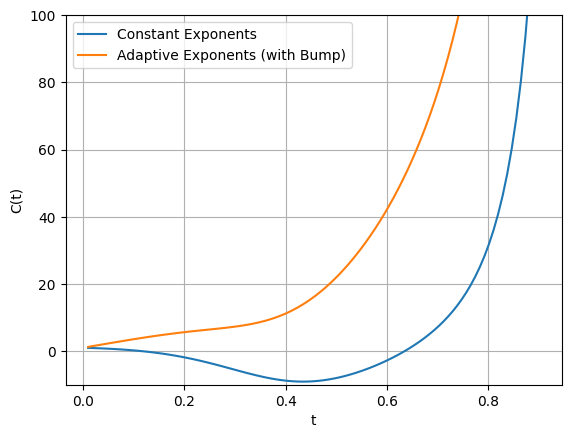

In [8]:
import torch
import matplotlib.pyplot as plt


# names = ["cos_t", "sigmoid", "1-t**2"]
# names = ["1-t**2", "sigmoid", "cos_t"] # (0.7316, 0.9025)
# names = ["1-t**2", "sigmoid", "1-t**2"] # (0.703, 0.921)
names = ["default_linear", "custom_poly", "default_linear"] #-> Bump = 14 works
# names = ["sigmoid", "ddpm_linear", "sigmoid"] # -> Bump = 5 works
# names = ["1-t**2", "default_linear", "1-t**2"]

print(names)
experiment_id = "."

Bump = 0
gamma_list = [
    lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),
    lambda t : torch.tensor(1) * torch.tensor(-1) ,
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t) + torch.tensor(Bump * (1 - 2*t)),
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t)
]

Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99999) = {Criterion(torch.tensor(0.99999)).item()}")

t = torch.linspace(0.01, 0.9, 100)
plt.plot(t.numpy(), Criterion(t).numpy(), label="Constant Exponents")
plt.xlabel('t')
plt.ylabel('C(t)')
# plt.title('Evolution of Criterion C(t) over time')
plt.grid(True)


Bump = 30
gamma_list = [
    lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),
    lambda t : torch.tensor(1) * torch.tensor(-1) ,
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t) + torch.tensor(Bump * (1 - 2*t)),
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t)
]

Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99999) = {Criterion(torch.tensor(0.99999)).item()}")

t = torch.linspace(0.01, 0.9, 100)
plt.plot(t.numpy(), Criterion(t).numpy(), label='Adaptive Exponents (with Bump)')
# plt.plot(label=r'C(t)>0 $\Rightarrow$ Marginal Path Existence')
# plt.plot(label=r'C(t)<0 $\Rightarrow$ Marginal Path Collapse')
plt.legend()
plt.ylim((-10,100))
plt.savefig(os.path.join(experiment_id, f"Criterion_plot_{names}_Bump{Bump}.png"))
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion(t): pos -> neg at t =", t[i].item())
        break
for i in range(len(t)-1):
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion(t) neg -> pos at t =", t[i].item())
        break